<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Var-Reduction-Speed" data-toc-modified-id="Var-Reduction-Speed-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Var Reduction Speed</a></span></li><li><span><a href="#Var-Reduction" data-toc-modified-id="Var-Reduction-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Var Reduction</a></span><ul class="toc-item"><li><span><a href="#Dimensional-wise-Test-Taker-Percentage" data-toc-modified-id="Dimensional-wise-Test-Taker-Percentage-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Dimensional-wise Test Taker Percentage</a></span></li></ul></li><li><span><a href="#Posterior-Mean-vs-True-Theta" data-toc-modified-id="Posterior-Mean-vs-True-Theta-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Posterior Mean vs True Theta</a></span></li><li><span><a href="#Posterior-Mean-v.s-Oracle-Mean" data-toc-modified-id="Posterior-Mean-v.s-Oracle-Mean-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Posterior Mean v.s Oracle Mean</a></span></li><li><span><a href="#Posterior-Median-v.s-Oracle-Median" data-toc-modified-id="Posterior-Median-v.s-Oracle-Median-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Posterior Median v.s Oracle Median</a></span></li><li><span><a href="#Posterior-First-Quantile-v.s-Oracle-First-Quantile" data-toc-modified-id="Posterior-First-Quantile-v.s-Oracle-First-Quantile-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Posterior First Quantile v.s Oracle First Quantile</a></span></li><li><span><a href="#Posterior-Third-Quantile-v.s-Oracle-Third-Quantile" data-toc-modified-id="Posterior-Third-Quantile-v.s-Oracle-Third-Quantile-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Posterior Third Quantile v.s Oracle Third Quantile</a></span></li><li><span><a href="#Training-Rewards-And-Validation-Loss" data-toc-modified-id="Training-Rewards-And-Validation-Loss-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Training Rewards And Validation Loss</a></span><ul class="toc-item"><li><span><a href="#Process-Rewards" data-toc-modified-id="Process-Rewards-8.1"><span class="toc-item-num">8.1&nbsp;&nbsp;</span>Process Rewards</a></span></li></ul></li></ul></div>

In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
import yaml
import argparse
import pandas as pd
import bayesian_cat as bcat
sns.set()

In [2]:
model_dir = pathlib.Path.home().joinpath(pathlib.Path("bayesian-cat", "models"))
model_filenames = ["testings_standarized_5_factor_trig_s05_kl_eap_50_subset.pickle", "testings_standarized_5_factor_trig_s05_kl_pos_50_subset.pickle", "testings_standarized_5_factor_trig_s05_mi_sir_50_subset.pickle",
                    "testings_standarized_5_factor_trig_s05_predictive_variance_e_50_subset.pickle"]
# previous baseline model
model_keys = ["EAP","Max Pos", "MI", "Max Var"]
models = {}
for i, filename in enumerate(model_filenames):
    with open(model_dir.joinpath("sim_models").joinpath(filename), "rb") as input_file:
        models[model_keys[i]] = pickle.load(input_file)
# current deep q learning
q_cat_dir = model_dir.joinpath("q_learning").joinpath("Q-CAT")
Q_model_filenames = ["triag_5_s03_QCAT_50_retrain_retrainv1_NN_x01_lower_triag_500_150_5_4_150000_first3-0-1_detailed_v4_1.5e-05_128_30000_1000_0.16_retrain_fn_34000.pt_fn_38000.pt_final.pickle"]
Q_learning_keys = ["Q-Learning"]
model_keys += Q_learning_keys
for i, filename in enumerate(Q_model_filenames):
    with open(q_cat_dir.joinpath(filename), "rb") as input_file:
        models[Q_learning_keys[i]] = pickle.load(input_file)

# read params and data
n, max_items=500, 50
num_models = len(model_keys)
model = models["MI"]
m,k = model.m, model.k
true_thetas = model.true_thetas
alphas = model.alphas
intercepts = model.intercepts

In [3]:
# Oracle Distribution
# params = {"thetas": true_thetas, "alphas": alphas, "intercepts": intercepts}
# simulated_item_response = bcat.util.probit_mirt_binary_data(params).values
# oracle = bcat.OracleCAT(simulated_item_response, params)
# bayes_oracle = oracle.sun_inference(1000, return_samples=True)
# bayes_oracle["response"] = simulated_item_response
# with open('bayesian_oracle_exact.pickle', 'wb') as handle:
#      pickle.dump(bayes_oracle, handle, protocol=pickle.HIGHEST_PROTOCOL)
with open('bayesian_oracle_exact.pickle', 'rb') as handle:
    bayes_oracle = pickle.load(handle)

In [4]:
true_samples= bayes_oracle["samples"][:n]
true_quantiles = {0.25:np.zeros((n, k)), 0.5:np.zeros((n, k)), 0.75 :np.zeros((n, k)), "oracle_mean": np.zeros((n,k))} # keys: 1, 2, 3 Vals: [],[],[]
for i in range(n):
    temp_sample = true_samples[i]
    for quantile in true_quantiles.keys():
        if quantile == "oracle_mean":
            true_quantiles[quantile][i]= np.mean(temp_sample, axis=0)
        else:
            true_quantiles[quantile][i] = np.quantile(temp_sample, quantile, axis=0)

# Var Reduction Speed

**It took around 40 minutes to run this chuck if you wish to uncomment the code block to do it from scratch.**

In [5]:
# Record Quantile result
# Quantile_result key is model, value is a disctionary: with key as 
# quantile_result = {}
# for model_name, model in models.items():
#     if model_name in quantile_result:
#         continue 
#     if model_name not in quantile_result:
#         print(model_name)
#         model_quantiles = {}
#         max_var_array = np.zeros((n, max_items))
#         max_mse_array = np.zeros((n, max_items))
#         if model_name[0] != "Q":
#             d1_tensor = model.tts.d1_tensor[:n, :max_items, :]
#             d2_array = model.tts.d2_array[:n, :max_items]
#             s_array = model.tts.s_array[:n, :max_items]
#         else:
#             d1_tensor = model.tts.d1_tensor[:n, 1:(max_items+1), :]
#             d2_array = model.tts.d2_array[:n, 1:(max_items+1)]
#             s_array = model.tts.s_array[:n, 1:(max_items+1)]
#         for j in range(max_items):
#             model_quantiles[j] = {0.25:np.zeros((n, k)), 0.5:np.zeros((n, k)), 0.75 :np.zeros((n, k)),
#                                  "var": np.zeros((n,k))}
#             model_samples = bcat.sample_from_sun_all(1000, d1_tensor[:,:(j+1),:], d2_array[:, :(j+1)],  s_array[:, :(j+1)], num_workers =8)
#             model_quantiles[j]["var"] = np.var(model_samples, axis=1)
#             for quantile in true_quantiles.keys():
#                 if quantile == "oracle_mean":
#                     model_quantiles[j][quantile] = np.mean(model_samples, axis=1)
#                 else:
#                     model_quantiles[j][quantile] = np.quantile(model_samples, quantile, axis=1)
#         quantile_result[model_name] = model_quantiles

# with open("quantile_result_new_eval_first_3.pickle", 'wb') as handle:
#     pickle.dump(quantile_result, handle, protocol=pickle.HIGHEST_PROTOCOL)


with open('quantile_result_new_eval_first_3.pickle', 'rb') as handle:
    quantile_result = pickle.load(handle)

# Var Reduction

## Dimensional-wise Test Taker Percentage

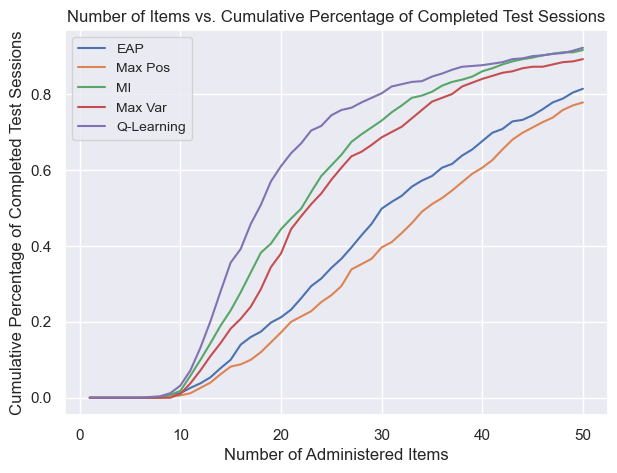

In [6]:
# Ensure figure is explicitly created
fig, ax = plt.subplots(figsize=(7,5))
x_vals = np.arange(1,max_items+1,1)
threshold = 0.16
for model_name, model in models.items():
    nonterminated_set = set(np.arange(0, n, 1))
    percentage = np.zeros(max_items)
    
    for h in range(max_items):
        cur_nonterminated = np.where(np.max(quantile_result[model_name][h]["var"][:, :3], axis=1) > threshold)[0]
        nonterminated_set = nonterminated_set.intersection(cur_nonterminated)
        percentage[h] = (n - len(nonterminated_set)) / n
    if model_name[0] == "Q":
        model_name = "Q-Learning"
    ax.plot(x_vals, percentage, label=model_name)

# Labels and legend
ax.set_title("Number of Items vs. Cumulative Percentage of Completed Test Sessions", fontsize=12)
ax.set_xlabel("Number of Administered Items", fontsize=12)
ax.set_ylabel("Cumulative Percentage of Completed Test Sessions", fontsize=12)
ax.legend(fontsize=10)

# Save the figure BEFORE plt.show()
plt.savefig("simulation_completion_rate.pdf", format="pdf", dpi=300, bbox_inches='tight')
plt.show()


In [7]:
threshold = 0.16
model_names = list(models.keys())
average_termination = {}
for model_name, model in models.items():
    count = 0
    nonterminated_set = set(np.arange(0,n,1))
    for h in range(max_items):
        cur_nonterminated = np.where(np.max(quantile_result[model_name][h]["var"][:, :3], axis=1) > threshold)[0]
        nonterminated_set = nonterminated_set.intersection(cur_nonterminated)
        count+= len(nonterminated_set)
    average_termination[model_name] = count/n

In [8]:
average_termination

{'EAP': 31.704,
 'Max Pos': 33.95,
 'MI': 24.178,
 'Max Var': 25.716,
 'Q-Learning': 21.5}

# Posterior Mean v.s Oracle Mean

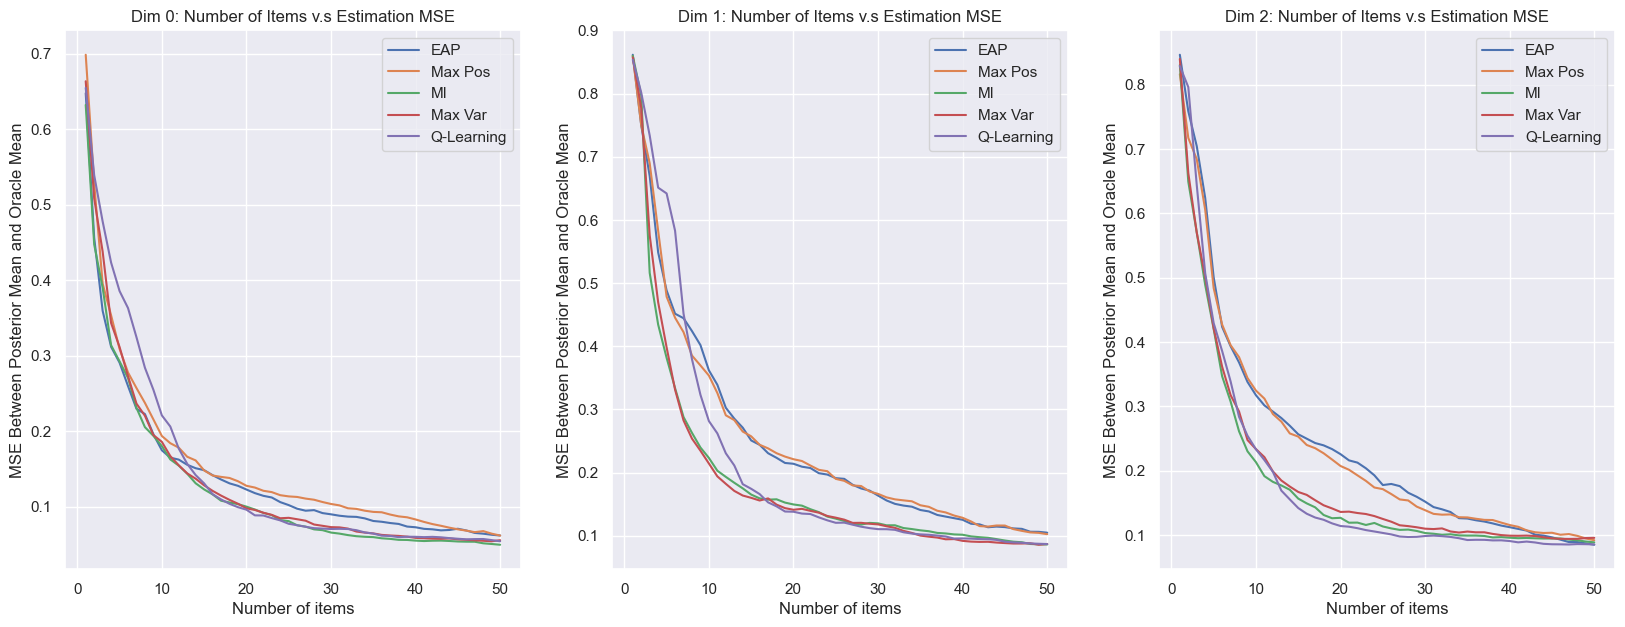

In [9]:
max_items = 50
x_vals = np.arange(1, max_items+1, 1)
test_taker_percentage = {}
fig, axs = plt.subplots(1, 3, figsize=(20, 7))

# Plot and save
for dim in range(3):
    for model_name, model in models.items():
        mse = np.zeros(max_items)
        for h in range(max_items):
            mse[h] = np.mean(np.square(quantile_result[model_name][h]["oracle_mean"][:, dim] - true_quantiles["oracle_mean"][:, dim]))
        if model_name[0] == "Q":
            model_name = "Q-Learning"
        axs[dim].plot(x_vals, mse, label=model_name)
    
    axs[dim].set_xlabel("Number of items")
    axs[dim].set_ylabel("MSE Between Posterior Mean and Oracle Mean")
    axs[dim].legend()
    axs[dim].set_title("Dim {}: Number of Items v.s Estimation MSE".format(dim))

# Save the figure to a PDF file
plt.savefig("simulation_mean_mse.pdf", format="pdf")

# Show the plot
plt.show()

In [10]:
max_items =20
winshare_tables = np.zeros((len(models.keys()),3))
model_names = list(models.keys())
for dim in range(3):
    mse_table = np.zeros((n, len(model_names)))
    for i, model_name in enumerate(model_names):
        mse_table[:, i] = np.square(quantile_result[model_name][max_items-1]["oracle_mean"][:, dim] -  true_quantiles["oracle_mean"][:, dim])
    winners = np.argmin(mse_table, axis=1)
    winshare_columns = np.zeros(len(model_names))
    for i, model_name in enumerate(model_names):
        winshare_columns[i] = np.sum(winners==i)/n
    winshare_tables[:, dim] = winshare_columns
        
winshare_tables= pd.DataFrame(winshare_tables, columns = ["dim"+str(dim) for dim in range(3)])
winshare_tables.index = model_names
winshare_tables

,dim0,dim1,dim2
EAP,0.170,0.164,0.136
Max Pos,0.168,0.162,0.186
MI,0.190,0.214,0.202
Max Var,0.236,0.226,0.236
Q-Learning,0.236,0.234,0.240


In [11]:
winshare_tables["avg_termination"] = winshare_tables.index.map(average_termination) 

In [12]:
winshare_tables

,dim0,dim1,dim2,avg_termination
EAP,0.170,0.164,0.136,31.704
Max Pos,0.168,0.162,0.186,33.950
MI,0.190,0.214,0.202,24.178
Max Var,0.236,0.226,0.236,25.716
Q-Learning,0.236,0.234,0.240,21.500


In [13]:
winshare_tables.transpose()

,EAP,Max Pos,MI,Max Var,Q-Learning
dim0,0.170,0.168,0.190,0.236,0.236
dim1,0.164,0.162,0.214,0.226,0.234
dim2,0.136,0.186,0.202,0.236,0.240
avg_termination,31.704,33.950,24.178,25.716,21.500


In [14]:
item_thresholds = [10, 20, 30, 40, 50]
mse_tables = {}
for dim in range(3):
    mse_table = np.zeros((len(model_names),len(item_thresholds)))
    for i, model_name in enumerate(model_names):
        for j, item in enumerate(item_thresholds):
            mse_table[i,j] = np.mean(np.square(quantile_result[model_name][item-1]["oracle_mean"][:, dim] -  true_quantiles["oracle_mean"][:, dim]))
    mse_tables[dim] = mse_table

In [15]:
mse_tables[0]

array([[0.17482845, 0.12285856, 0.09001629, 0.072865  , 0.06198006],
       [0.1937454 , 0.12779666, 0.10371237, 0.08321017, 0.06191369],
       [0.1803737 , 0.10020329, 0.06586907, 0.05519133, 0.04972184],
       [0.18598479, 0.09793789, 0.07304451, 0.05884957, 0.05573661],
       [0.22103919, 0.09616101, 0.07055465, 0.06022627, 0.0543072 ]])

In [16]:
mse_tables[1]

array([[0.36188758, 0.21402864, 0.16366084, 0.12533326, 0.10494214],
       [0.35362463, 0.22121988, 0.16635814, 0.12850746, 0.10258629],
       [0.22325398, 0.14962458, 0.11971283, 0.1016893 , 0.08630469],
       [0.21444083, 0.14121032, 0.11807905, 0.09198046, 0.08708757],
       [0.28161715, 0.13810733, 0.11051683, 0.09585584, 0.08694359]])

In [17]:
mse_tables[2]

array([[0.31724153, 0.22561768, 0.1518549 , 0.11214391, 0.08484696],
       [0.32442808, 0.20725867, 0.13854075, 0.11549616, 0.09194769],
       [0.21317416, 0.12672686, 0.1030579 , 0.09577732, 0.08860042],
       [0.23351883, 0.13582945, 0.10981307, 0.09894881, 0.09558515],
       [0.23319712, 0.11395639, 0.09843292, 0.09060315, 0.08537694]])

# Quantiles

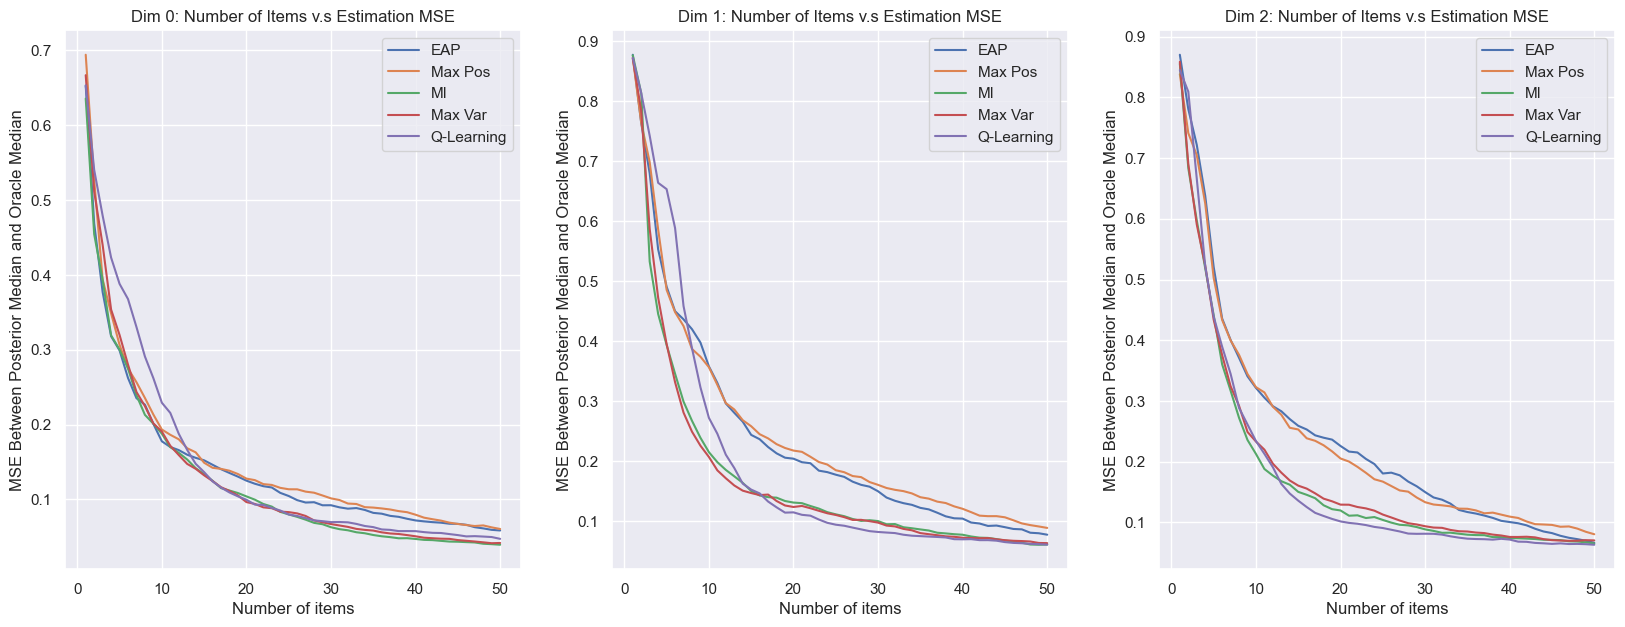

In [19]:
max_items = 50
x_vals = np.arange(1,max_items+1,1)
test_taker_percentage = {}
fig, axs = plt.subplots(1, 3, figsize=(20, 7))
for dim in range(3):
    for model_name, model in models.items():
        mse = np.zeros(max_items)
        for h in range(max_items):
            mse[h] = np.mean(np.square(quantile_result[model_name][h][0.5][:, dim] - true_thetas[:, dim]))
        if model_name[0] =="Q":
            model_name = "Q-Learning"
        axs[dim].plot(x_vals, mse, label=model_name)
    axs[dim].set_xlabel("Number of items")
    axs[dim].set_ylabel("MSE Between Posterior Median and Oracle Median")
    axs[dim].legend()
    axs[dim].set_title("Dim {}: Number of Items v.s Estimation MSE".format(dim))

# Save the figure to a PDF file
plt.savefig("simulation_median_mse.pdf", format="pdf")

# Show the plot
plt.show()

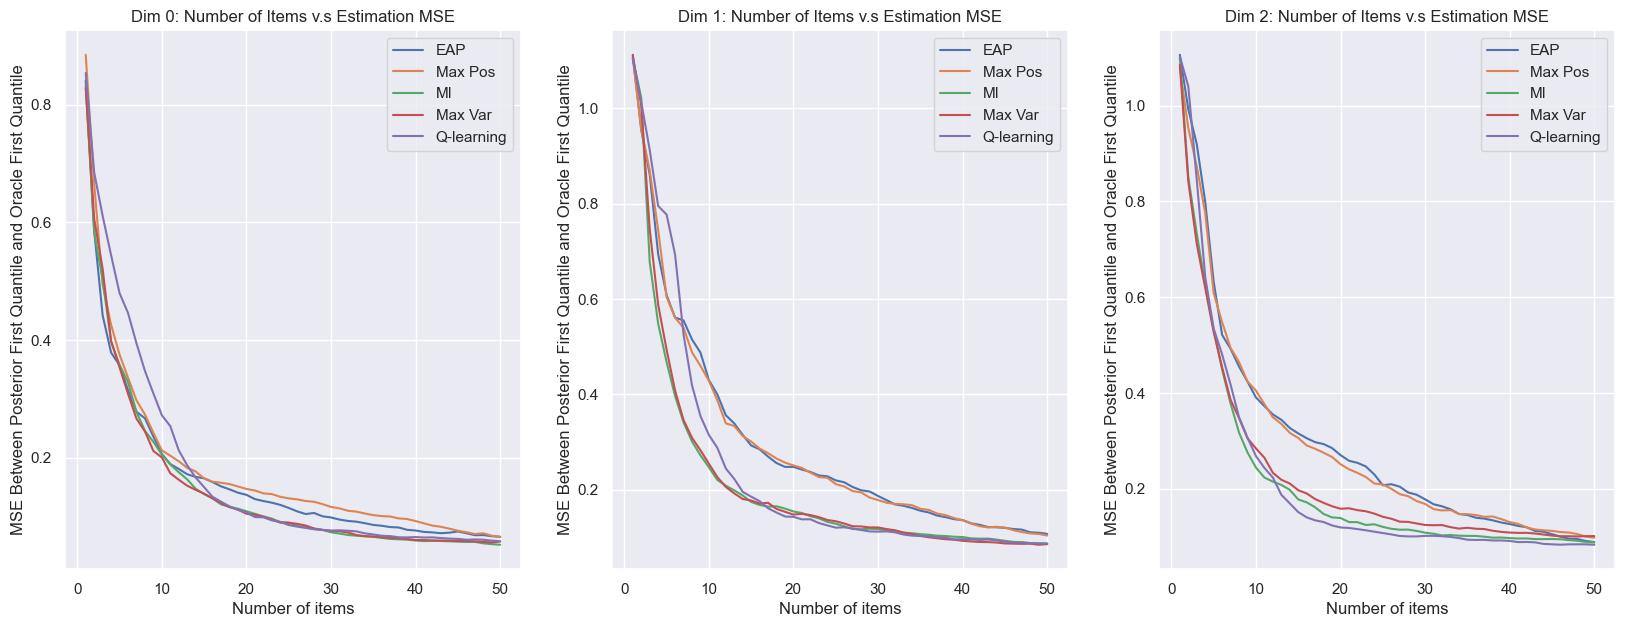

In [20]:
max_items = 50
x_vals = np.arange(1,max_items+1,1)
test_taker_percentage = {}
fig, axs = plt.subplots(1, 3, figsize=(20, 7))
for dim in range(3):
    for model_name, model in models.items():
        mse = np.zeros(max_items)
        for h in range(max_items):
            mse[h] = np.mean(np.square(quantile_result[model_name][h][0.25][:, dim] - true_quantiles[0.25][:, dim]))
        if model_name[0] == "Q":
            model_name = "Q-learning"
        axs[dim].plot(x_vals, mse, label=model_name)
    axs[dim].set_xlabel("Number of items")
    axs[dim].set_ylabel("MSE Between Posterior First Quantile and Oracle First Quantile")
    axs[dim].legend()
    axs[dim].set_title("Dim {}: Number of Items v.s Estimation MSE".format(dim))

# Save the figure to a PDF file
plt.savefig("simulation_1st_quantile_mse.pdf", format="pdf")

# Show the plot
plt.show()

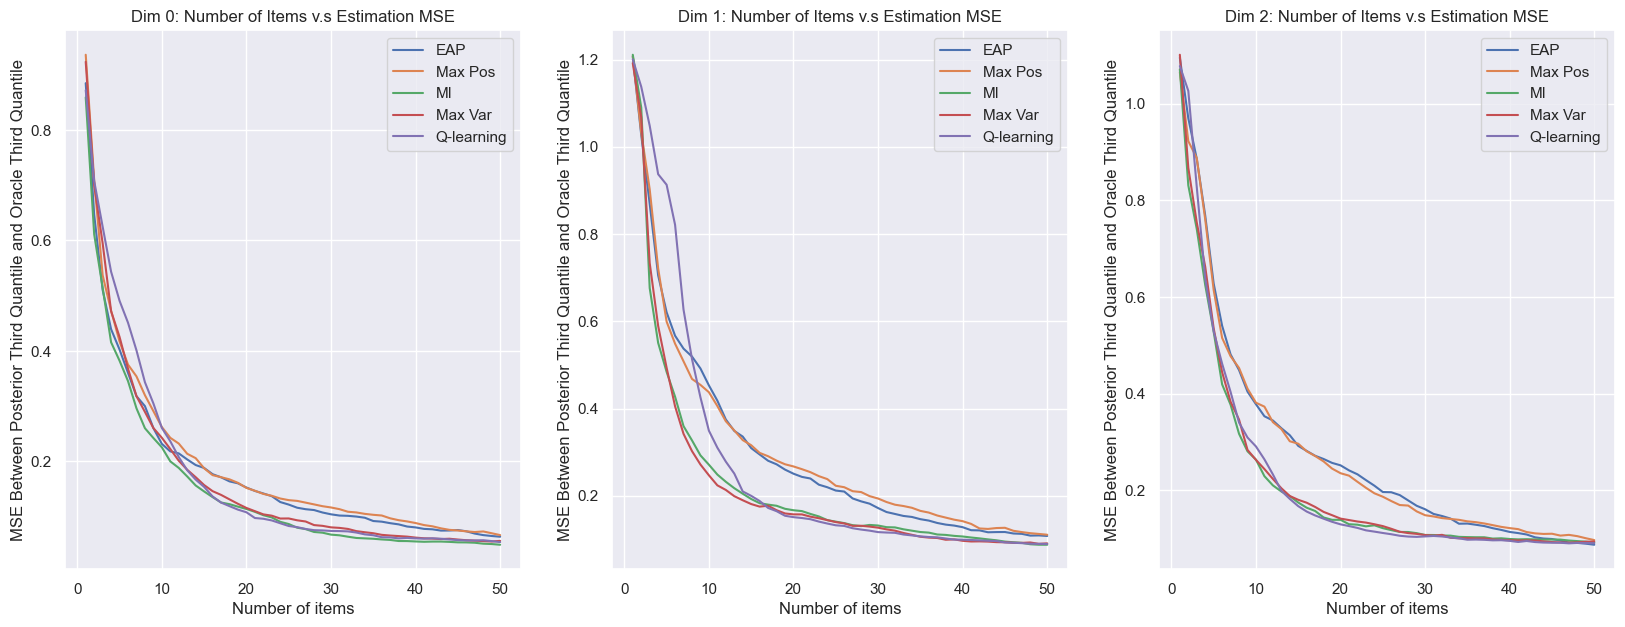

In [21]:
max_items  = 50
x_vals = np.arange(1,max_items+1,1)
test_taker_percentage = {}
fig, axs = plt.subplots(1, 3, figsize=(20, 7))
for dim in range(3):
    for model_name, model in models.items():
        mse = np.zeros(max_items)
        for h in range(max_items):
            mse[h] = np.mean(np.square(quantile_result[model_name][h][0.75][:, dim] - true_quantiles[0.75][:, dim]))
        if model_name[0] == "Q":
            model_name = "Q-learning"
        axs[dim].plot(x_vals, mse, label=model_name)
    axs[dim].set_xlabel("Number of items")
    axs[dim].set_ylabel("MSE Between Posterior Third Quantile and Oracle Third Quantile")
    axs[dim].legend()
    axs[dim].set_title("Dim {}: Number of Items v.s Estimation MSE".format(dim))

# Save the figure to a PDF file
plt.savefig("simulation_3rd_quantile_mse.pdf", format="pdf")

# Show the plot
plt.show()

# Factor Loading Visualization

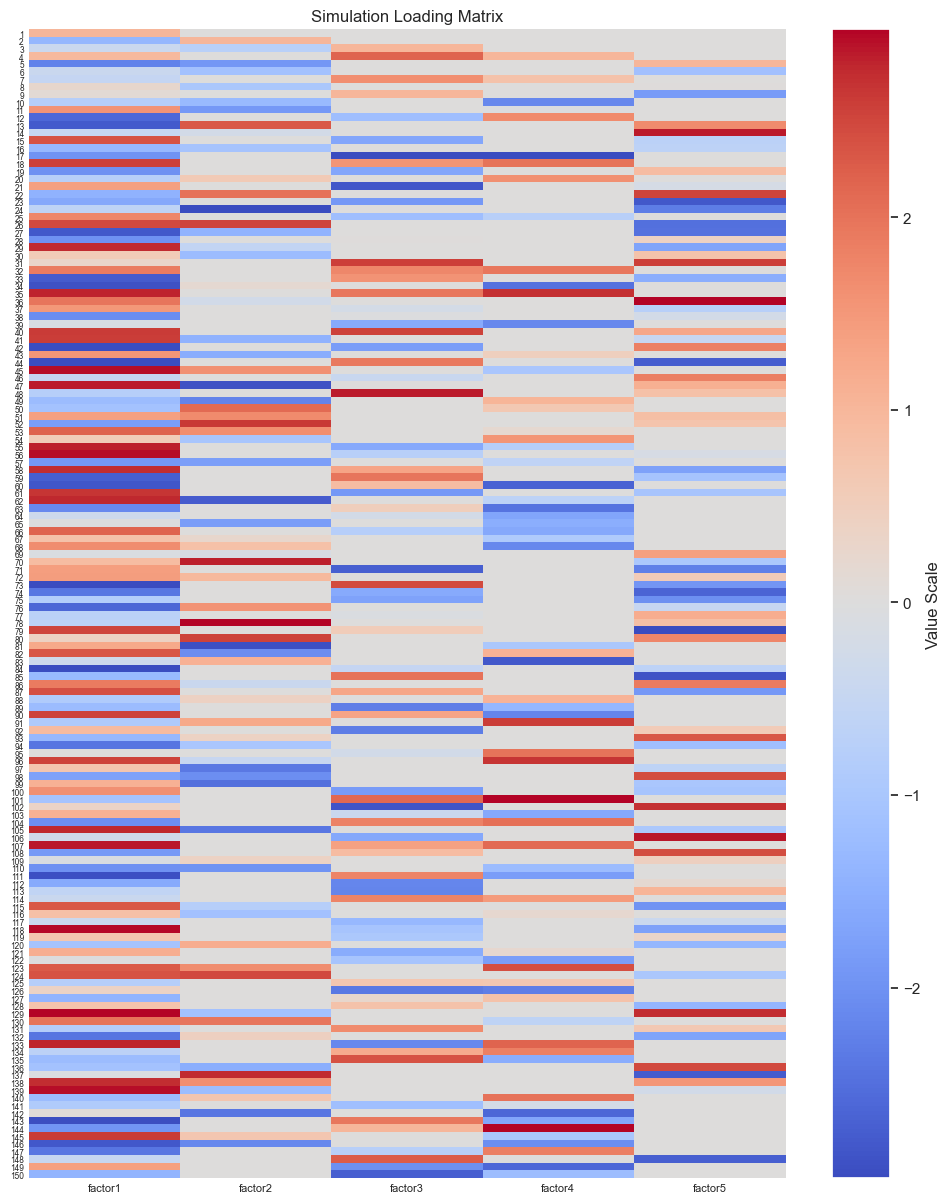

Plot saved as simulation_loadings.pdf


In [22]:
# Create the plot
# Example n x 4 array (mostly zeros)
#all_items = response_df.columns

num_items= alphas.shape[0] # Number of rows


# Row labels (example labels)
row_labels = [str(i) for i in range(1,151)]
col_labels = ["factor"+str(i) for i in range(1,6)]

fig, ax = plt.subplots(figsize=(10, 12))
#factor_loadings = alphas / np.sqrt(1 + np.sum(alphas**2, axis=1, keepdims=True))
factor_loadings = alphas
cax = ax.imshow(factor_loadings, cmap='coolwarm', aspect='auto', interpolation='none')  # No interpolation to remove white gaps

# Add color bar
cbar = plt.colorbar(cax, ax=ax)
cbar.set_label('Value Scale')

# Set row and column labels
ax.set_yticks(np.arange(num_items))
ax.set_yticklabels(row_labels, fontsize=6)

ax.set_xticks(np.arange(5))
ax.set_xticklabels(col_labels, fontsize=8)

# Remove spines (borders) for a cleaner look
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove all grid lines and ticks to eliminate white lines
ax.tick_params(axis='both', which='both', length=0)

# Ensure no vertical gaps between columns
ax.set_xticks(np.arange(-0.5, 4, 1), minor=True)
ax.grid(False)  # Disable grid lines

# Adjust layout for minimal presentation
plt.tight_layout()

# Save the plot as a PDF file
pdf_filename = "simulation_loadings.pdf"
plt.savefig(pdf_filename, format='pdf', bbox_inches='tight', dpi=300)
plt.title("Simulation Loading Matrix")
# Display the plot
plt.show()

print(f"Plot saved as {pdf_filename}")

## Training rewards

In [23]:
with open("detailed_log.pickle", "rb") as input_file:
    training_log1 = pickle.load(input_file)
with open("retrain_retrainv1_detailed_log.pickle", "rb") as input_file:
    training_log2 = pickle.load(input_file)

In [24]:
len(training_log1)

35001

In [25]:
len(training_log2)

44001

In [26]:
episode_rewards1 = np.array([training_log1[i]["learned_reward"] for i in range(len(training_log1))])
episode_rewards2 = np.array([training_log2[i]["learned_reward"] for i in range(len(training_log2))])
episode_rewards = np.concatenate((episode_rewards1, episode_rewards2))
reward_period = 500
plot_length = episode_rewards.shape[0]//reward_period
average_rewards = np.zeros(plot_length)
for i in range(plot_length):
    average_rewards[i] = np.mean(episode_rewards[(i*reward_period):((i+1)*reward_period)])

In [27]:
plt.plot(np.arange(0, len(average_rewards)*500, 500), average_rewards)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Training Performance")

# Save as a high-quality vector PDF
plt.tight_layout()
plt.savefig("average_rewards_simulations.pdf", format="pdf", bbox_inches="tight")
plt.close()


## Exposure Rate

In [29]:
def compute_exposure_rates(item_selections, n_items=None):
    """
    item_selections: (N, T) array of item IDs
    n_items: total number of items J 
    returns: exposure_rates of shape (J,), e_j in [0, 1]
    """

    S = np.asarray(item_selections, dtype=int)
    N, T = S.shape
    if n_items is None:
        n_items = int(S.max())  # assumes items are labeled 1..J

    exposure = np.zeros(n_items, dtype=float)
    for j in range(0, n_items):
        used_by_i = (S == j).any(axis=1)
        exposure[j] = used_by_i.mean()   # proportion of examinees
    return exposure


J=150
alg_names = ['EAP', 'Max Pos', 'MI', 'Max Var', 'Q-Learning']
exposure_dict = {}
for name in alg_names:
    S = models[name].item_selections   # (N, T)
    exposure_dict[name] = compute_exposure_rates(S, n_items=J)


In [33]:

# infer number of items J from all models
all_max = max(int(models[name].item_selections.max()) for name in alg_names)
J = all_max

exposure_dict = {}
for name in alg_names:
    S = models[name].item_selections   # (N, T)
    exposure_dict[name] = compute_exposure_rates(S, n_items=J)

# expected mean exposure ≈ T/J
some_S = models[alg_names[0]].item_selections
T = some_S.shape[1]
expected_mean = T / J

data = [exposure_dict[name]*100 for name in alg_names]

fig, ax = plt.subplots(figsize=(6, 3.5))

# Since we horizontally plot bar charts, orders needed to be reverted 
alg_names_plot = alg_names[::-1]
data_plot = data[::-1]

bp = ax.boxplot(
    data_plot,
    vert=False,              # horizontal boxplots
    labels=alg_names_plot,
    showfliers=True,
    patch_artist=True
)

colors = ['#fee8c8', '#fdbb84', '#e34a33', '#b3cde3', '#8c96c6']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.axvline(expected_mean*100, linestyle='--', linewidth=1, color='gray',
           label=r'average exposure')

ax.set_xlabel('Item exposure rate (%)')
#ax.set_ylabel('CAT algorithm')



ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('item_exposure_boxplots.pdf')
plt.close()

In [31]:
rows = []
for name in alg_names:
    exp = exposure_dict[name]
    row = {
        'mean_exp': exp.mean(),
        'expected_T_over_J': expected_mean,
        'min_exp': exp.min(),
        'q25_exp': np.quantile(exp, 0.25),
        'median_exp': np.median(exp),
        'q75_exp': np.quantile(exp, 0.75),
        'max_exp': exp.max(),
        'prop_exp>0.4': (exp > 0.4).mean(),
        'prop_exp>0.5': (exp > 0.5).mean(),
    }
    rows.append(row)

exposure_summary = pd.DataFrame(rows, index=alg_names)
print(exposure_summary)

            mean_exp  expected_T_over_J  min_exp  q25_exp  median_exp  \
EAP         0.331799            0.33557      0.0    0.070       0.364   
Max Pos     0.333463            0.33557      0.0    0.188       0.336   
MI          0.331718            0.33557      0.0    0.190       0.352   
Max Var     0.332322            0.33557      0.0    0.262       0.330   
Q-Learning  0.332859            0.33557      0.0    0.078       0.318   

            q75_exp  max_exp  prop_exp>0.4  prop_exp>0.5  
EAP           0.536      1.0      0.456376      0.322148  
Max Pos       0.456      1.0      0.369128      0.208054  
MI            0.454      1.0      0.375839      0.161074  
Max Var       0.402      1.0      0.255034      0.100671  
Q-Learning    0.536      1.0      0.389262      0.275168  
